# Dataset Preparing

In [ ]:
DATASET_PATH='write dataset path here'

In [ ]:
import os
import cv2
import torch
import random
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

class LOLDataset(Dataset):
    def __init__(self, root_dir, phase='train', patch_size=256):
        self.root_dir = root_dir
        self.phase = phase
        self.patch_size = patch_size

        self.low_dir = os.path.join(root_dir, phase, 'low')
        self.high_dir = os.path.join(root_dir, phase, 'high')

        self.image_filenames = [f for f in os.listdir(self.low_dir) if f.endswith(('.png', '.jpg'))]

    def __len__(self):
        return len(self.image_filenames)

    def __getitem__(self, idx):
        img_name = self.image_filenames[idx]

        low_img_path = os.path.join(self.low_dir, img_name)
        high_img_path = os.path.join(self.high_dir, img_name)

        low_img = cv2.imread(low_img_path)
        high_img = cv2.imread(high_img_path)

        low_img = cv2.cvtColor(low_img, cv2.COLOR_BGR2RGB)
        high_img = cv2.cvtColor(high_img, cv2.COLOR_BGR2RGB)

        low_tensor = torch.from_numpy(low_img.transpose((2, 0, 1))).float() / 255.0
        high_tensor = torch.from_numpy(high_img.transpose((2, 0, 1))).float() / 255.0

        if self.phase == 'train':
            _, h, w = low_tensor.shape

            top = random.randint(0, h - self.patch_size)
            left = random.randint(0, w - self.patch_size)

            low_tensor = TF.crop(low_tensor, top, left, self.patch_size, self.patch_size)
            high_tensor = TF.crop(high_tensor, top, left, self.patch_size, self.patch_size)

            if random.random() > 0.5:
                low_tensor = TF.hflip(low_tensor)
                high_tensor = TF.hflip(high_tensor)

        return low_tensor, high_tensor, img_name

if __name__ == "__main__":

    os.makedirs(os.path.join(DATASET_PATH, 'train', 'low'), exist_ok=True)
    os.makedirs(os.path.join(DATASET_PATH, 'train', 'high'), exist_ok=True)

    train_dataset = LOLDataset(root_dir=DATASET_PATH, phase='train', patch_size=256)

    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=4)

    print(f"Toplam eğitim görüntüsü sayısı: {len(train_dataset)}")

    if len(train_dataset) > 0:
        low_imgs, high_imgs, names = next(iter(train_loader))
        print(f"Low Image Batch Shape: {low_imgs.shape}")
        print(f"High Image Batch Shape: {high_imgs.shape}")

Toplam eğitim görüntüsü sayısı: 485


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Low Image Batch Shape: torch.Size([8, 3, 256, 256])
High Image Batch Shape: torch.Size([8, 3, 256, 256])


# Model Architecture

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ConvBlock, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, padding_mode='reflect'),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, padding_mode='reflect'),
            nn.LeakyReLU(0.2, inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

class SharedEncoder(nn.Module):
    def __init__(self):
        super(SharedEncoder, self).__init__()
        self.enc1 = ConvBlock(3, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = ConvBlock(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = ConvBlock(64, 128)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = ConvBlock(128, 256)

    def forward(self, x):
        f1 = self.enc1(x)
        f2 = self.enc2(self.pool1(f1))
        f3 = self.enc3(self.pool2(f2))
        bottle = self.bottleneck(self.pool3(f3))
        return bottle, f3, f2, f1

class DecoderBranch(nn.Module):
    def __init__(self, is_illumination=False):
        super(DecoderBranch, self).__init__()
        self.is_illumination = is_illumination

        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec3 = ConvBlock(256, 128)
        self.out_quarter = nn.Conv2d(128, 3, kernel_size=1)

        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = ConvBlock(128, 64)
        self.out_half = nn.Conv2d(64, 3, kernel_size=1)

        self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec1 = ConvBlock(64, 32)
        self.out_full = nn.Conv2d(32, 3, kernel_size=1)

    def forward(self, bottle, f3, f2, f1):

        x = self.up3(bottle)
        x = torch.cat([x, f3], dim=1)
        x = self.dec3(x)
        out_1_4 = self.out_quarter(x)

        x = self.up2(x)
        x = torch.cat([x, f2], dim=1)
        x = self.dec2(x)
        out_1_2 = self.out_half(x)

        x = self.up1(x)
        x = torch.cat([x, f1], dim=1)
        x = self.dec1(x)
        out_1_1 = self.out_full(x)


        if self.is_illumination:
            out_1_4 = torch.sigmoid(out_1_4)
            out_1_2 = torch.sigmoid(out_1_2)
            out_1_1 = torch.sigmoid(out_1_1)

        return out_1_4, out_1_2, out_1_1

class DualBranchDecompNet(nn.Module):
    def __init__(self):
        super(DualBranchDecompNet, self).__init__()
        self.encoder = SharedEncoder()

        self.illumination_branch = DecoderBranch(is_illumination=True)
        self.residual_branch = DecoderBranch(is_illumination=False)

    def forward(self, x):
        bottle, f3, f2, f1 = self.encoder(x)

        ill_1_4, ill_1_2, ill_full = self.illumination_branch(bottle, f3, f2, f1)
        res_1_4, res_1_2, res_full = self.residual_branch(bottle, f3, f2, f1)

        enhanced_1_4 = ill_1_4 + res_1_4
        enhanced_1_2 = ill_1_2 + res_1_2
        enhanced_full = ill_full + res_full

        return {
            'enhanced': [enhanced_1_4, enhanced_1_2, enhanced_full],
            'illumination': [ill_1_4, ill_1_2, ill_full],
            'residual': [res_1_4, res_1_2, res_full]
        }

if __name__ == '__main__':

    dummy_input = torch.randn(8, 3, 256, 256)

    model = DualBranchDecompNet()

    outputs = model(dummy_input)

    print("Multi-Scale Enhanced Outputs Shapes:")
    print("1/4 Ölçek:", outputs['enhanced'][0].shape)
    print("1/2 Ölçek:", outputs['enhanced'][1].shape)
    print("Tam Ölçek:", outputs['enhanced'][2].shape)
    print("\nModel başarıyla çalışıyor! Parametre sayısı:", sum(p.numel() for p in model.parameters() if p.requires_grad))

Multi-Scale Enhanced Outputs Shapes:
1/4 Ölçek: torch.Size([8, 3, 64, 64])
1/2 Ölçek: torch.Size([8, 3, 128, 128])
Tam Ölçek: torch.Size([8, 3, 256, 256])

Model başarıyla çalışıyor! Parametre sayısı: 2680242


Loss Function

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ExposureLoss(nn.Module):
    def __init__(self, patch_size=16, mean_val=0.6):
        super(ExposureLoss, self).__init__()
        self.pool = nn.AvgPool2d(patch_size)
        self.mean_val = mean_val

    def forward(self, enhanced):
        x = self.pool(enhanced)
        loss = torch.mean(torch.pow(x - self.mean_val, 2))
        return loss

class SpatialConsistencyLoss(nn.Module):
    def __init__(self):
        super(SpatialConsistencyLoss, self).__init__()
        self.left_pool = nn.AvgPool2d(4, stride=4)
        self.right_pool = nn.AvgPool2d(4, stride=4)
        self.up_pool = nn.AvgPool2d(4, stride=4)
        self.down_pool = nn.AvgPool2d(4, stride=4)

    def forward(self, original, enhanced):
        org_pool = nn.AvgPool2d(4, stride=4)(original)
        enh_pool = nn.AvgPool2d(4, stride=4)(enhanced)

        D_org_left = org_pool[:, :, :, :-1] - org_pool[:, :, :, 1:]
        D_org_right = org_pool[:, :, :, 1:] - org_pool[:, :, :, :-1]
        D_org_up = org_pool[:, :, :-1, :] - org_pool[:, :, 1:, :]
        D_org_down = org_pool[:, :, 1:, :] - org_pool[:, :, :-1, :]

        D_enh_left = enh_pool[:, :, :, :-1] - enh_pool[:, :, :, 1:]
        D_enh_right = enh_pool[:, :, :, 1:] - enh_pool[:, :, :, :-1]
        D_enh_up = enh_pool[:, :, :-1, :] - enh_pool[:, :, 1:, :]
        D_enh_down = enh_pool[:, :, 1:, :] - enh_pool[:, :, :-1, :]

        loss = (torch.mean(torch.abs(D_org_left - D_enh_left)) +
                torch.mean(torch.abs(D_org_right - D_enh_right)) +
                torch.mean(torch.abs(D_org_up - D_enh_up)) +
                torch.mean(torch.abs(D_org_down - D_enh_down)))
        return loss

class GradientLoss(nn.Module):
    def __init__(self):
        super(GradientLoss, self).__init__()
    def forward(self, pred, gt):
        pred_dx = torch.abs(pred[:, :, :, :-1] - pred[:, :, :, 1:])
        pred_dy = torch.abs(pred[:, :, :-1, :] - pred[:, :, 1:, :])
        gt_dx = torch.abs(gt[:, :, :, :-1] - gt[:, :, :, 1:])
        gt_dy = torch.abs(gt[:, :, :-1, :] - gt[:, :, 1:, :])

        loss = torch.mean(torch.abs(pred_dx - gt_dx)) + torch.mean(torch.abs(pred_dy - gt_dy))
        return loss
class ColorLoss(nn.Module):
    def __init__(self):
        super(ColorLoss, self).__init__()

    def forward(self, pred, gt):
        cos_sim = F.cosine_similarity(pred, gt, dim=1)

        loss = torch.mean(1.0 - cos_sim)
        return loss

class TotalLoss(nn.Module):
    def __init__(self, lambda_ms=1.0, lambda_spa=0.5, lambda_exp=10.0, lambda_col=0.5):
        super(TotalLoss, self).__init__()
        self.lambda_ms = lambda_ms
        self.lambda_spa = lambda_spa
        self.lambda_exp = lambda_exp
        self.lambda_col = lambda_col

        self.l1_loss = nn.L1Loss()
        self.grad_loss = GradientLoss()
        self.exposure_loss = ExposureLoss()
        self.spatial_loss = SpatialConsistencyLoss()
        self.color_loss = ColorLoss()

    def forward(self, outputs, low_img, high_img):
        pred_1_4, pred_1_2, pred_full = outputs['enhanced']

        gt_1_4 = F.interpolate(high_img, scale_factor=0.25, mode='bilinear', align_corners=False)
        gt_1_2 = F.interpolate(high_img, scale_factor=0.5, mode='bilinear', align_corners=False)
        gt_full = high_img

        loss_ms = 0
        for pred, gt in zip([pred_1_4, pred_1_2, pred_full], [gt_1_4, gt_1_2, gt_full]):
            loss_ms += self.l1_loss(pred, gt) + (5.0 * self.grad_loss(pred, gt))
        loss_ms = loss_ms / 3.0

        loss_exp = self.exposure_loss(outputs['illumination'][2])

        loss_spa = self.spatial_loss(low_img, pred_full)

        loss_col = self.color_loss(pred_full, gt_full)

        total_loss = (self.lambda_ms * loss_ms) + \
                     (self.lambda_spa * loss_spa) + \
                     (self.lambda_exp * loss_exp) + \
                     (self.lambda_col * loss_col)

        return total_loss, {
            'loss_ms': loss_ms.item(),
            'loss_spa': loss_spa.item(),
            'loss_exp': loss_exp.item(),
            'loss_col': loss_col.item()
        }

if __name__ == '__main__':
    batch_size = 8
    dummy_outputs = {
        'enhanced': [
            torch.rand(batch_size, 3, 64, 64),
            torch.rand(batch_size, 3, 128, 128),
            torch.rand(batch_size, 3, 256, 256)
        ],
        'illumination': [None, None, torch.rand(batch_size, 3, 256, 256)]
    }

    dummy_low_img = torch.rand(batch_size, 3, 256, 256)
    dummy_high_img = torch.rand(batch_size, 3, 256, 256)

    criterion = TotalLoss(lambda_ms=1.0, lambda_spa=0.5, lambda_exp=10.0)

    total_loss, loss_dict = criterion(dummy_outputs, dummy_low_img, dummy_high_img)

    print(f"Toplam Loss: {total_loss.item():.4f}")
    print("Loss Detayları:")
    print(f"- Multi-Scale Loss: {loss_dict['loss_ms']:.4f}")
    print(f"- Spatial Consistency Loss: {loss_dict['loss_spa']:.4f}")
    print(f"- Exposure Control Loss: {loss_dict['loss_exp']:.4f}")
    print("\nLoss modülü başarıyla çalışıyor! Geri yayılım (backprop) için hazır.")

Toplam Loss: 3.2428
Loss Detayları:
- Multi-Scale Loss: 2.8074
- Spatial Consistency Loss: 0.4604
- Exposure Control Loss: 0.0104

Loss modülü başarıyla çalışıyor! Geri yayılım (backprop) için hazır.


Training

In [ ]:
import os
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm

class Config:
    dataset_dir = DATASET_PATH
    save_dir = './checkpoints'

    epochs = 100
    batch_size = 8
    lr = 1e-4
    patch_size = 256

    lambda_ms = 2.0
    lambda_spa = 0.05
    lambda_exp = 1.0
    lambda_col = 0.5

def train_colab():
    args = Config()

    os.makedirs(args.save_dir, exist_ok=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Eğitim başlıyor. Kullanılan cihaz: {device}")
    print(f"Hiperparametreler: Lambda_Spa={args.lambda_spa}, Lambda_Exp={args.lambda_exp}")

    train_dataset = LOLDataset(root_dir=args.dataset_dir, phase='train', patch_size=args.patch_size)
    train_loader = DataLoader(train_dataset, batch_size=args.batch_size, shuffle=True, num_workers=2)

    model = DualBranchDecompNet().to(device)

    criterion = TotalLoss(
        lambda_ms=args.lambda_ms,
        lambda_spa=args.lambda_spa,
        lambda_exp=args.lambda_exp
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=args.lr)

    for epoch in range(1, args.epochs + 1):
        model.train()
        epoch_loss = 0.0

        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch}/{args.epochs}", leave=False)

        for low_img, high_img, _ in progress_bar:
            low_img = low_img.to(device)
            high_img = high_img.to(device)

            optimizer.zero_grad()

            outputs = model(low_img)
            loss, loss_dict = criterion(outputs, low_img, high_img)

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

            progress_bar.set_postfix({
                'Total': f"{loss.item():.3f}",
                'Spa': f"{loss_dict['loss_spa']:.3f}",
                'Exp': f"{loss_dict['loss_exp']:.3f}"
            })

        avg_loss = epoch_loss / len(train_loader)
        print(f"Epoch [{epoch}/{args.epochs}] Tamamlandı | Ortalama Loss: {avg_loss:.4f}")

        if epoch % 10 == 0:
            save_path = os.path.join(args.save_dir, f"epoch_{epoch}_spa_{args.lambda_spa}_exp_{args.lambda_exp}.pth")
            torch.save(model.state_dict(), save_path)
            print(f"--> Model kaydedildi: {save_path}")

train_colab()

Eğitim başlıyor. Kullanılan cihaz: cuda
Hiperparametreler: Lambda_Spa=0.05, Lambda_Exp=1.0


Epoch 1/100:   0%|          | 0/61 [00:00<?, ?it/s]

Epoch [1/100] Tamamlandı | Ortalama Loss: 0.9331


Epoch 2/100:   0%|          | 0/61 [00:00<?, ?it/s]

Epoch [2/100] Tamamlandı | Ortalama Loss: 0.8715


...

Epoch [98/100] Tamamlandı | Ortalama Loss: 0.5435


Epoch 99/100:   0%|          | 0/61 [00:00<?, ?it/s]

Epoch [99/100] Tamamlandı | Ortalama Loss: 0.5347


Epoch 100/100:   0%|          | 0/61 [00:00<?, ?it/s]

Epoch [100/100] Tamamlandı | Ortalama Loss: 0.5407
--> Model kaydedildi: /content/drive/MyDrive/ComputerVisionProject/checkpoints_run4/epoch_100_spa_0.05_exp_1.0.pth


# Test

Test cihazı: cuda
Toplam 485 test görüntüsü işleniyor...



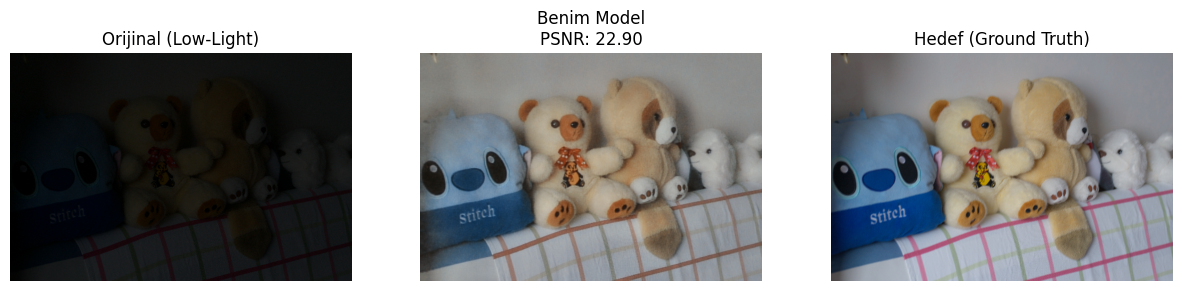

------------------------------
TEST SONUÇLARI (Ortalama):
PSNR: 18.2471 dB
SSIM: 0.8094
Tüm sonuçlar '/content/drive/MyDrive/ComputerVisionProject/results4' klasörüne kaydedildi.


In [ ]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as calculate_psnr
from skimage.metrics import structural_similarity as calculate_ssim

WEIGHT_PATH = '/checkpoints/epoch_100_spa_0.05_exp_1.0.pth'

TEST_LOW_DIR = DATASET_PATH + '/train/low'
TEST_HIGH_DIR = DATASET_PATH + '/train/high'
SAVE_DIR = '/results'
os.makedirs(SAVE_DIR, exist_ok=True)

def tensor_to_image(tensor):
    """PyTorch tensörünü ekranda göstermek/kaydetmek için numpy dizisine çevirir"""
    image = tensor.squeeze(0).cpu().numpy()
    image = np.transpose(image, (1, 2, 0))
    image = (np.clip(image, 0, 1) * 255.0).astype(np.uint8)
    return image

def test_model():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Test cihazı: {device}")

    model = DualBranchDecompNet().to(device)
    model.load_state_dict(torch.load(WEIGHT_PATH, map_location=device))
    model.eval()

    psnr_list, ssim_list = [], []
    image_names = [f for f in os.listdir(TEST_LOW_DIR) if f.endswith(('.png', '.jpg'))]

    print(f"Toplam {len(image_names)} test görüntüsü işleniyor...\n")

    with torch.no_grad():
        for img_name in image_names:
            low_img = cv2.imread(os.path.join(TEST_LOW_DIR, img_name))
            high_img = cv2.imread(os.path.join(TEST_HIGH_DIR, img_name))

            low_img = cv2.cvtColor(low_img, cv2.COLOR_BGR2RGB)
            high_img = cv2.cvtColor(high_img, cv2.COLOR_BGR2RGB)

            input_tensor = torch.from_numpy(low_img.transpose((2, 0, 1))).float().unsqueeze(0) / 255.0
            input_tensor = input_tensor.to(device)

            outputs = model(input_tensor)

            enhanced_tensor = outputs['enhanced'][2]

            enhanced_img = tensor_to_image(enhanced_tensor)

            psnr_val = calculate_psnr(high_img, enhanced_img)
            ssim_val = calculate_ssim(high_img, enhanced_img, channel_axis=2, data_range=255)

            psnr_list.append(psnr_val)
            ssim_list.append(ssim_val)


            save_path = os.path.join(SAVE_DIR, img_name)
            cv2.imwrite(save_path, cv2.cvtColor(enhanced_img, cv2.COLOR_RGB2BGR))

            if img_name == image_names[0]:
                plt.figure(figsize=(15, 5))
                plt.subplot(1, 3, 1)
                plt.title("Orijinal (Low-Light)")
                plt.imshow(low_img)
                plt.axis('off')

                plt.subplot(1, 3, 2)
                plt.title(f"Benim Model\nPSNR: {psnr_val:.2f}")
                plt.imshow(enhanced_img)
                plt.axis('off')

                plt.subplot(1, 3, 3)
                plt.title("Hedef (Ground Truth)")
                plt.imshow(high_img)
                plt.axis('off')
                plt.show()

    print("-" * 30)
    print("TEST SONUÇLARI (Ortalama):")
    print(f"PSNR: {np.mean(psnr_list):.4f} dB")
    print(f"SSIM: {np.mean(ssim_list):.4f}")
    print(f"Tüm sonuçlar '{SAVE_DIR}' klasörüne kaydedildi.")

test_model()

Karşılaştırma ZERO DCE

In [ ]:

!git clone https://github.com/Li-Chongyi/Zero-DCE.git

!mkdir -p /baselines
!mv Zero-DCE /baselines

Cloning into 'Zero-DCE'...
remote: Enumerating objects: 236, done.
remote: Counting objects: 100% (39/39), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 236 (delta 30), reused 28 (delta 28), pack-reused 197 (from 1)
Receiving objects: 100% (236/236), 30.89 MiB | 34.23 MiB/s, done.
Resolving deltas: 100% (43/43), done.


In [ ]:

!mkdir -p /baselines/Zero-DCE/Zero-DCE_code/data/test_data/

!cp -r {DATASET_PATH}/train/low* /baselines/Zero-DCE/Zero-DCE_code/data/test_data/

In [ ]:

%cd /baselines/Zero-DCE/Zero-DCE_code
!python lowlight_test.py

/content/drive/MyDrive/ComputerVisionProject/baselines/Zero-DCE/Zero-DCE_code
data/test_data/DICM/37.jpg
0.3561387062072754
data/test_data/DICM/58.jpg
0.010285615921020508
data/test_data/DICM/20.jpg
0.011210203170776367
data/test_data/DICM/14.jpg
0.007596015930175781
data/test_data/DICM/46.jpg
0.0015294551849365234
data/test_data/DICM/62.jpg
0.0016782283782958984
data/test_data/DICM/64.jpg
0.0015006065368652344
data/test_data/DICM/41.jpg
0.007593393325805664
data/test_data/DICM/11.jpg
0.0014476776123046875
data/test_data/DICM/54.jpg
0.0014352798461914062
data/test_data/DICM/61.jpg
0.006914615631103516
data/test_data/DICM/33.jpg
0.009679079055786133
data/test_data/DICM/28.jpg
0.0018775463104248047
data/test_data/DICM/03.jpg
0.001995563507080078
data/test_data/DICM/30.jpg
0.008024930953979492
data/test_data/DICM/38.jpg
0.00770878791809082
data/test_data/DICM/56.jpg
0.0014605522155761719
data/test_data/DICM/44.jpg
0.007798671722412109
data/test_data/DICM/49.jpg
0.0016055107116699219
data/

Zero DCE test

In [ ]:
import os
import cv2
import numpy as np
from skimage.metrics import peak_signal_noise_ratio as calculate_psnr
from skimage.metrics import structural_similarity as calculate_ssim

ZERO_DCE_RESULTS = '/baselines/Zero-DCE/Zero-DCE_code/data/result/low'

GROUND_TRUTH_DIR = DATASET_PATH + '/train/high'
gt_image_names = [f for f in os.listdir(GROUND_TRUTH_DIR) if f.endswith(('.png', '.jpg', '.jpeg'))]

psnr_list, ssim_list = [], []

print(f"Sadece kendi LOL veri setimizdeki {len(gt_image_names)} fotoğraf için test yapılıyor...\n")

for gt_name in gt_image_names:
    gt_path = os.path.join(GROUND_TRUTH_DIR, gt_name)
    base_name = os.path.splitext(gt_name)[0]

    pred_path_png = os.path.join(ZERO_DCE_RESULTS, f"{base_name}.png")
    pred_path_jpg = os.path.join(ZERO_DCE_RESULTS, f"{base_name}.jpg")

    if os.path.exists(pred_path_png):
        pred_path = pred_path_png
    elif os.path.exists(pred_path_jpg):
        pred_path = pred_path_jpg
    else:
        print(f"UYARI: Zero-DCE '{base_name}' fotoğrafını işlememiş! Atlanıyor...")
        continue

    pred_img = cv2.imread(pred_path)
    gt_img = cv2.imread(gt_path)

    if pred_img.shape != gt_img.shape:
        pred_img = cv2.resize(pred_img, (gt_img.shape[1], gt_img.shape[0]))

    pred_img = cv2.cvtColor(pred_img, cv2.COLOR_BGR2RGB)
    gt_img = cv2.cvtColor(gt_img, cv2.COLOR_BGR2RGB)

    psnr_val = calculate_psnr(gt_img, pred_img)
    ssim_val = calculate_ssim(gt_img, pred_img, channel_axis=2, data_range=255)

    psnr_list.append(psnr_val)
    ssim_list.append(ssim_val)

if len(psnr_list) == 0:
    print("\nHATA: Hiçbir fotoğraf eşleşmedi. Klasör yollarını kontrol et!")
else:
    print("-" * 30)
    print(f"GERÇEK ZERO-DCE TEST SONUÇLARI ({len(psnr_list)} LOL görüntüsü):")
    print(f"PSNR: {np.mean(psnr_list):.4f} dB")
    print(f"SSIM: {np.mean(ssim_list):.4f}")

Sadece kendi LOL veri setimizdeki 485 fotoğraf için test yapılıyor...

------------------------------
GERÇEK ZERO-DCE TEST SONUÇLARI (485 LOL görüntüsü):
PSNR: 14.1405 dB
SSIM: 0.5190


KiND Test

In [ ]:

!git clone https://github.com/zhangyhuaee/KinD.git /baselines/KinD/code

!mkdir -p /baselines/KinD/test_data
!rm -rf /baselines/KinD/test_data/*

!cp -r {DATASET_PATH}/train/low* /baselines/KinD/test_data/

Cloning into '/content/drive/MyDrive/ComputerVisionProject/baselines/KinD/code'...
remote: Enumerating objects: 182, done.
remote: Counting objects: 100% (177/177), done.
remote: Compressing objects: 100% (90/90), done.
remote: Total 182 (delta 84), reused 159 (delta 76), pack-reused 5 (from 1)
Receiving objects: 100% (182/182), 6.50 MiB | 19.52 MiB/s, done.
Resolving deltas: 100% (84/84), done.


In [ ]:
%cd /baselines/KinD/code
!python evaluate.py

/content/drive/MyDrive/ComputerVisionProject/baselines/KinD/code
2026-05-27 15:50:33.284660: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Instructions for updating:
non-resource variables are not supported in the long term
2026-05-27 15:50:37.728940: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1779897037.730373   13862 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
/usr/local/lib/python3.12/dist-packages/tensorflow/python/keras/engine/base_layer_v1.py:1694:

In [ ]:
import os
import shutil

kaynak = DATASET_PATH + "/train/low"
hedef = "/baselines/KinD/code/test"

os.makedirs(hedef, exist_ok=True)

for item in os.listdir(kaynak):
    s = os.path.join(kaynak, item)
    d = os.path.join(hedef, item)

    if os.path.isdir(s):
        shutil.copytree(s, d, dirs_exist_ok=True)
    else:
        shutil.copy2(s, d)

In [ ]:
import os
import cv2
import numpy as np
from skimage.metrics import peak_signal_noise_ratio as calculate_psnr
from skimage.metrics import structural_similarity as calculate_ssim

KIND_RESULTS = '/baselines/KinD/code/results/test'
GROUND_TRUTH_DIR = DATASET_PATH + '/train/high'

gt_image_names = [f for f in os.listdir(GROUND_TRUTH_DIR) if f.endswith(('.png', '.jpg', '.jpeg'))]
psnr_list, ssim_list = [], []

print(f"KinD çıktıları taranıyor... Toplam {len(gt_image_names)} LOL görüntüsü için test yapılıyor...\n")

for gt_name in gt_image_names:
    gt_path = os.path.join(GROUND_TRUTH_DIR, gt_name)
    base_name = os.path.splitext(gt_name)[0]

    pred_path_png = os.path.join(KIND_RESULTS, f"{base_name}_kindle.png")
    pred_path_jpg = os.path.join(KIND_RESULTS, f"{base_name}_kindle.jpg")

    if os.path.exists(pred_path_png):
        pred_path = pred_path_png
    elif os.path.exists(pred_path_jpg):
        pred_path = pred_path_jpg
    else:
        print(f"UYARI: KinD '{base_name}' fotoğrafını işlememiş! Atlanıyor...")
        continue

    pred_img = cv2.imread(pred_path)
    gt_img = cv2.imread(gt_path)

    if pred_img.shape != gt_img.shape:
        pred_img = cv2.resize(pred_img, (gt_img.shape[1], gt_img.shape[0]))

    pred_img = cv2.cvtColor(pred_img, cv2.COLOR_BGR2RGB)
    gt_img = cv2.cvtColor(gt_img, cv2.COLOR_BGR2RGB)

    psnr_val = calculate_psnr(gt_img, pred_img)
    ssim_val = calculate_ssim(gt_img, pred_img, channel_axis=2, data_range=255)

    psnr_list.append(psnr_val)
    ssim_list.append(ssim_val)

if len(psnr_list) == 0:
    print("\nHATA: Hiçbir fotoğraf eşleşmedi. KinD'nin çıktı klasörünü kontrol et!")
else:
    print("-" * 30)
    print(f"GERÇEK KinD TEST SONUÇLARI ({len(psnr_list)} LOL görüntüsü):")
    print(f"PSNR: {np.mean(psnr_list):.4f} dB")
    print(f"SSIM: {np.mean(ssim_list):.4f}")

KinD çıktıları taranıyor... Toplam 485 LOL görüntüsü için test yapılıyor...

------------------------------
GERÇEK KinD TEST SONUÇLARI (485 LOL görüntüsü):
PSNR: 19.5570 dB
SSIM: 0.8193


YOLO DETECTION Test

In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 29.5 MB/s eta 0:00:00



image 1/1 /content/drive/MyDrive/ComputerVisionProject/LOL/train/low/104.png: 448x640 1 bottle, 7.6ms
Speed: 2.2ms preprocess, 7.6ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /content/drive/MyDrive/ComputerVisionProject/results4/104.png: 448x640 1 bottle, 2 chairs, 6.8ms
Speed: 2.0ms preprocess, 6.8ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)


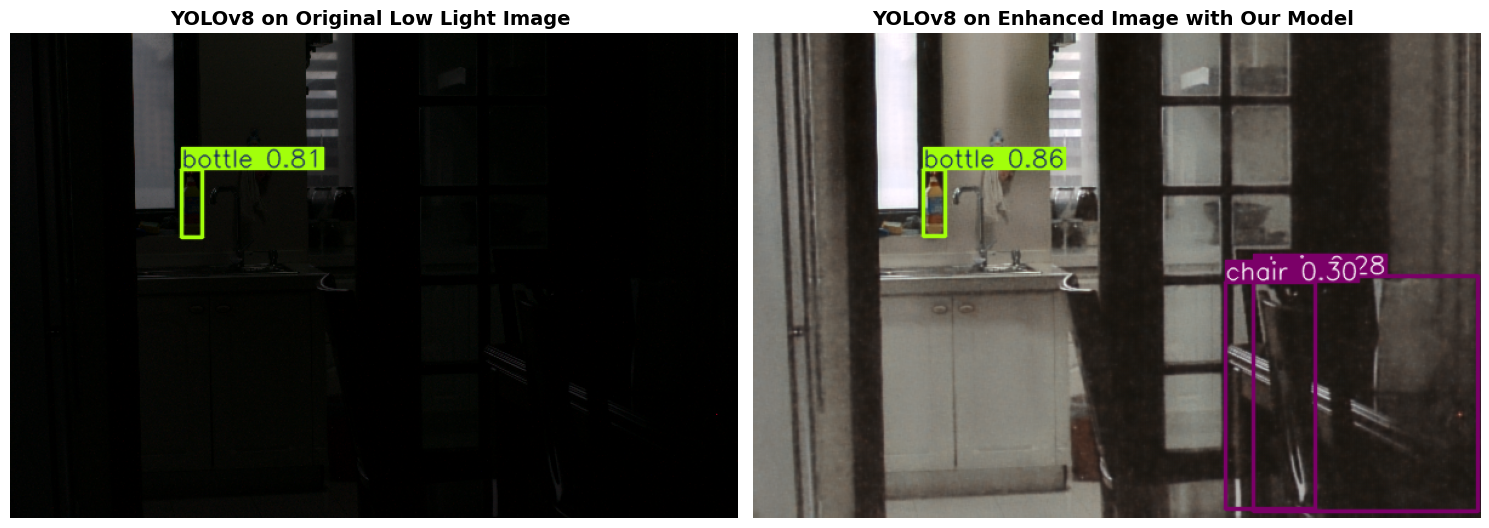

Karanlık fotoğrafta bulunan nesne sayısı: 1
Aydınlık fotoğrafta bulunan nesne sayısı: 3


In [ ]:

import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO


model = YOLO('yolov8n.pt')

img_name = '104.png'
orijinal_karanlik_yol = DATASET_PATH + '/train/low/{img_name}'

bizim_model_yol = f'/results/{img_name}'

results_karanlik = model.predict(source=orijinal_karanlik_yol, save=False, conf=0.25)
results_aydinlik = model.predict(source=bizim_model_yol, save=False, conf=0.25)

karanlik_cizimli = results_karanlik[0].plot()
aydinlik_cizimli = results_aydinlik[0].plot()

karanlik_cizimli = cv2.cvtColor(karanlik_cizimli, cv2.COLOR_BGR2RGB)
aydinlik_cizimli = cv2.cvtColor(aydinlik_cizimli, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.title("YOLOv8 on Original Low Light Image ", fontsize=14, fontweight='bold')
plt.imshow(karanlik_cizimli)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("YOLOv8 on Enhanced Image with Our Model ", fontsize=14, fontweight='bold')
plt.imshow(aydinlik_cizimli)
plt.axis('off')
plt.savefig('yolo_results.png', bbox_inches='tight', dpi=300)
plt.tight_layout()
plt.show()

print(f"Karanlık fotoğrafta bulunan nesne sayısı: {len(results_karanlik[0].boxes)}")
print(f"Aydınlık fotoğrafta bulunan nesne sayısı: {len(results_aydinlik[0].boxes)}")

Calculating Metrics (Which results path you give it test metrics)

In [ ]:
!pip install pyiqa

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 29.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 14.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 80.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.1/333.1 kB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.5/226.5 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.4/99.4 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 114.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4

In [ ]:
import os
import torch
import pyiqa
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("LPIPS ve NIQE modelleri indiriliyor (Sadece ilk seferde biraz sürer)...")
lpips_metric = pyiqa.create_metric('lpips', device=device)
niqe_metric = pyiqa.create_metric('niqe', device=device)

TEST_EDILECEK_KLASOR = '/baselines/KinD/code/results/test'
GROUND_TRUTH_DIR = DATASET_PATH + '/train/high'

image_names = [f for f in os.listdir(TEST_EDILECEK_KLASOR) if f.endswith(('.png', '.jpg', '.jpeg'))]

lpips_list, niqe_list = [], []

print(f"Toplam {len(image_names)} görüntü için LPIPS ve NIQE hesaplanıyor...\n")

for img_name in image_names:
    pred_path = os.path.join(TEST_EDILECEK_KLASOR, img_name)

    base_name = os.path.splitext(img_name)[0].replace('_kindle', '')

    gt_path_png = os.path.join(GROUND_TRUTH_DIR, f"{base_name}.png")
    gt_path_jpg = os.path.join(GROUND_TRUTH_DIR, f"{base_name}.jpg")

    if os.path.exists(gt_path_png):
        gt_path = gt_path_png
    elif os.path.exists(gt_path_jpg):
        gt_path = gt_path_jpg
    else:
        continue

    score_lpips = lpips_metric(pred_path, gt_path).item()
    lpips_list.append(score_lpips)

    score_niqe = niqe_metric(pred_path).item()
    niqe_list.append(score_niqe)

print("-" * 30)
print("Zero DCE - YENİ METRİK SONUÇLARI:")
print(f"LPIPS: {np.mean(lpips_list):.4f} (Daha düşük, daha iyi)")
print(f"NIQE:  {np.mean(niqe_list):.4f} (Daha düşük, daha iyi)")

LPIPS ve NIQE modelleri indiriliyor (Sadece ilk seferde biraz sürer)...
Loading pretrained model LPIPS from /root/.cache/torch/hub/pyiqa/LPIPS_v0.1_alex-df73285e.pth
Toplam 485 görüntü için LPIPS ve NIQE hesaplanıyor...

------------------------------
Zero DCE - YENİ METRİK SONUÇLARI:
LPIPS: 0.1575 (Daha düşük, daha iyi)
NIQE:  4.7192 (Daha düşük, daha iyi)
